 *** file saved ... figures/hopfield_sorted_states_2mem.txt


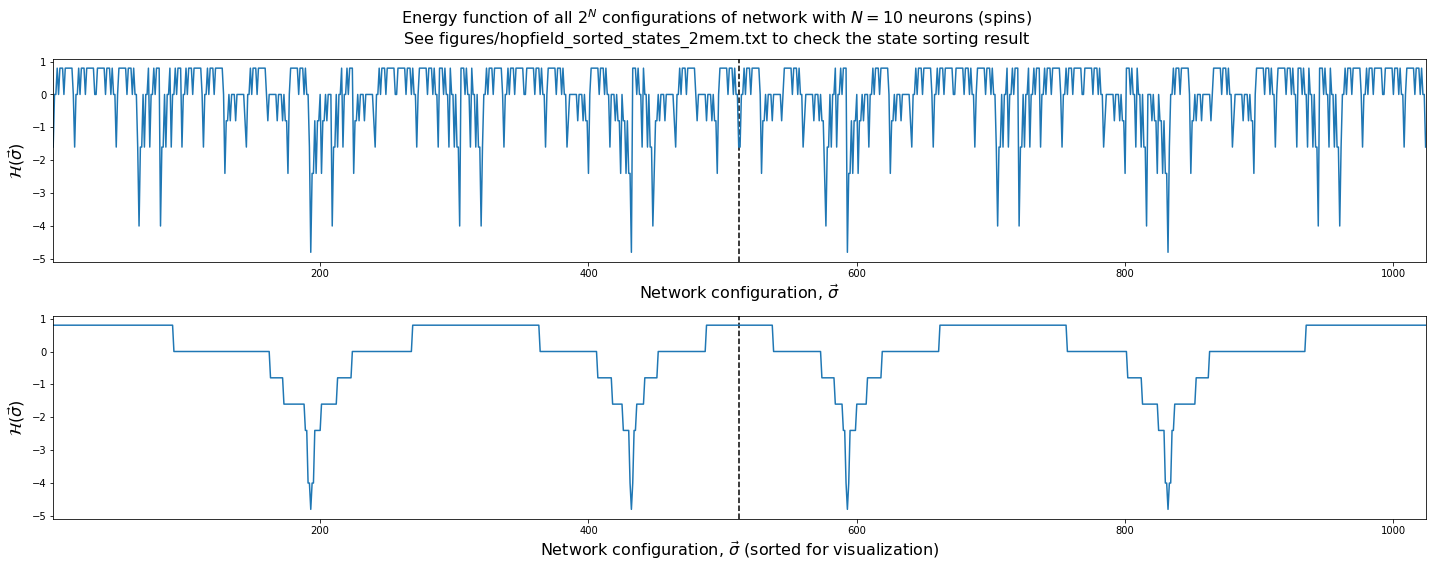

In [2]:
import modules.hopfield as hopfield
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(53)


state_to_str    = lambda state: ''.join([ ('+' if s>0 else '-') for s in state ])


N               = 10
P               = 2 # number of patterns
patterns        = [ 2*np.random.randint(2,size=N)-1 for mu in range(P) ]
add_anti_states = lambda S: np.vstack((S,-np.flipud(S)))

W,N,patterns  = hopfield.initialize_hopfield_model(patterns)
states_set    = add_anti_states(hopfield.generate_ising_states(N))
E             = np.array([hopfield.calculate_energy(W, s) for s in states_set])

states_sorted,sorted_ind,E_sorted = hopfield.sort_states_around_energy_minima(states_set, E, patterns)

hopfield.save_sorted_state_txt('figures/hopfield_sorted_states_2mem.txt',states_set, patterns, sorted_ind, states_sorted)


fig,ax = plt.subplots(2,1,sharey=True,figsize=(20,8))

ax[0].axvline(2**(N-1),ls='--',c='k')
ax[1].axvline(2**(N-1),ls='--',c='k')
ax[0].plot(np.arange(1,E.size+1       ),E)
ax[1].plot(np.arange(1,E_sorted.size+1),E_sorted)


ax[0].set_xlabel(r'Network configuration, $\vec{\sigma}$',fontsize=16)
ax[0].set_ylabel(r'$\mathcal{H}(\vec{\sigma})$',fontsize=16)
ax[1].set_xlabel(r'Network configuration, $\vec{\sigma}$ (sorted for visualization)',fontsize=16)
ax[1].set_ylabel(r'$\mathcal{H}(\vec{\sigma})$',fontsize=16)
ax[0].autoscale(enable=True, axis='x', tight=True)
ax[1].autoscale(enable=True, axis='x', tight=True)


fig.suptitle('Energy function of all $2^N$ configurations of network with $N=10$ neurons (spins)\nSee figures/hopfield_sorted_states_2mem.txt to check the state sorting result',fontsize=16)
fig.tight_layout()

fig.savefig('figures/hopfield_sorted_states_2mem.png', format='png', bbox_inches='tight')

plt.show()